# Data pre-processing and transformation


In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and deep learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, classification_report



Using Hourly data

**multi classes for sleep quality**

In [2]:
import pandas as pd

# Load minute-level sleep data
sleep_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/minuteSleep_merged.csv', parse_dates=['date'])

# Extract sleep date without time
sleep_df['SleepDate'] = sleep_df['date'].dt.date.astype('datetime64[ns]')

# Aggregate sleep stats per user per day
daily_sleep = sleep_df.groupby(['Id', 'SleepDate'])['value'].value_counts().unstack(fill_value=0)

# Rename columns to meaningful names
daily_sleep.rename(columns={1: 'TotalMinutesAsleep', 2: 'RestlessMinutes', 3: 'AwakeMinutes'}, inplace=True)

# Reset index to make it a proper dataframe
daily_sleep = daily_sleep.reset_index()

# 🛠 Define Sleep Quality Classes
def classify_sleep_quality(total_sleep, restless_mins):
    if total_sleep >= 390 and restless_mins <= 20:
        return 2  # Good Sleep (Long & Stable)
    elif total_sleep >= 390 and restless_mins > 20:
        return 1  # Moderate Sleep (Long but Restless)
    elif total_sleep >= 300 and restless_mins <= 30:
        return 1  # Moderate Sleep (Shorter but Stable)
    else:
        return 0  # Poor Sleep (Too Short or Highly Restless)

# Apply classification function
daily_sleep['SleepQuality'] = daily_sleep.apply(
    lambda row: classify_sleep_quality(row['TotalMinutesAsleep'], row['RestlessMinutes']), axis=1
)

# Load hourly steps and calories
steps_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv', parse_dates=['ActivityHour'])
calories_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv', parse_dates=['ActivityHour'])

# Merge activity data
activity_df = pd.merge(steps_df, calories_df, on=['Id', 'ActivityHour'])

# Load heart rate data
heartrate_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv', parse_dates=['Time'])

# Group by user ID first, then resample per hour
heartrate_hourly = heartrate_df.groupby('Id').resample('H', on='Time').agg({'Value': 'mean'}).reset_index()

# Merge activity and heart rate data
merged_df = pd.merge(
    activity_df,
    heartrate_hourly,
    left_on=['Id', 'ActivityHour'],
    right_on=['Id', 'Time'],
    how='inner'
)

# Extract Sleep Date from timestamps
merged_df['SleepDate'] = merged_df['ActivityHour'].dt.date.astype('datetime64[ns]')

# Merge with sleep data
final_df = pd.merge(
    merged_df,
    daily_sleep[['Id', 'SleepDate', 'SleepQuality']],
    left_on=['Id', 'SleepDate'],
    right_on=['Id', 'SleepDate'],
    how='inner'
)

# Calculate Stress Level (deviation from resting heart rate)
resting_hr = final_df.groupby('Id')['Value'].quantile(0.25).reset_index()
resting_hr.columns = ['Id', 'RestingHR']
final_df = pd.merge(final_df, resting_hr, on='Id')
final_df['StressLevel'] = final_df['Value'] - final_df['RestingHR']
final_df.drop('RestingHR', axis=1, inplace=True)

# Keep key features
final_df = final_df[['Id', 'ActivityHour', 'StepTotal', 'Calories', 'Value', 'StressLevel', 'SleepQuality']]
final_df.columns = ['UserId', 'Hour', 'Steps', 'Calories', 'AvgHeartRate', 'StressLevel', 'SleepQuality']

# Display final dataframe
print(final_df.head())


<ipython-input-2-1439c521e9ae>:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  steps_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv', parse_dates=['ActivityHour'])
<ipython-input-2-1439c521e9ae>:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calories_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv', parse_dates=['ActivityHour'])


       UserId                Hour  Steps  Calories  AvgHeartRate  StressLevel  \
0  2026352035 2016-04-17 05:00:00     36        50     67.198630    -9.949518   
1  2026352035 2016-04-17 06:00:00    214        69     73.282609    -3.865539   
2  2026352035 2016-04-17 07:00:00    116        63           NaN          NaN   
3  2026352035 2016-04-17 08:00:00    130        61           NaN          NaN   
4  2026352035 2016-04-17 09:00:00    119        61           NaN          NaN   

   SleepQuality  
0             1  
1             1  
2             1  
3             1  
4             1  


In [4]:
# Drop rows where AvgHeartRate (Value) is NaN
final_df = final_df.dropna(subset=['AvgHeartRate'])


In [5]:
final_df

,UserId,Hour,Steps,Calories,AvgHeartRate,StressLevel,SleepQuality
0,2026352035,2016-04-17 05:00:00,36,50,67.198630,-9.949518,1
1,2026352035,2016-04-17 06:00:00,214,69,73.282609,-3.865539,1
196,2026352035,2016-04-25 09:00:00,672,113,105.139706,27.991558,1
197,2026352035,2016-04-25 10:00:00,120,73,95.693291,18.545143,1
198,2026352035,2016-04-25 11:00:00,484,79,105.880597,28.732449,1
...,...,...,...,...,...,...,...
5056,8792009665,2016-05-04 06:00:00,0,72,74.549689,11.375885,1
5057,8792009665,2016-05-04 07:00:00,0,73,71.149123,7.975319,1
5058,8792009665,2016-05-04 08:00:00,0,72,72.860947,9.687143,1
5059,8792009665,2016-05-04 09:00:00,31,78,70.016393,6.842589,1


In [6]:
# Count occurrences of each SleepQuality class
sleep_quality_counts = final_df['SleepQuality'].value_counts()
print(sleep_quality_counts)


SleepQuality
1    2196
2    1166
0     757
Name: count, dtype: int64


In [7]:
final_df.to_csv('final_df.csv', index=False)

# Multi classification model(CNN-LSTM)

In [8]:
final_df = pd.read_csv('/kaggle/input/hourly-final/final_df (1).csv',  parse_dates=['Hour'])


In [9]:

print(final_df[['Steps', 'Calories', 'AvgHeartRate', 'StressLevel']].describe())


             Steps     Calories  AvgHeartRate  StressLevel
count  4119.000000  4119.000000   4119.000000  4119.000000
mean    394.464433   107.841952     71.995596     8.845575
std     656.599369    65.928932     13.447252    12.126416
min       0.000000    50.000000     43.354037   -16.295497
25%       6.000000    65.000000     62.428373    -0.000480
50%     139.000000    85.000000     69.457584     6.663981
75%     501.000000   124.000000     80.060421    15.246327
max    5890.000000   612.000000    150.206208    78.910711


In [10]:


final_df.dropna(inplace=True)

# Normalize features
scaler = MinMaxScaler()
features = scaler.fit_transform(
    final_df[['Steps', 'Calories', 'AvgHeartRate', 'StressLevel']]
)

labels = final_df['SleepQuality'].values

In [11]:
# Create sequences (16-hour windows -> predict next sleep quality)
def create_sequences(features, labels, user_ids, seq_length=16):
    X, y = [], []
    for user_id in final_df['UserId'].unique():
        user_mask = (final_df['UserId'] == user_id)
        user_features = features[user_mask]
        user_labels = labels[user_mask]
        
        # Create sequences per user
        for i in range(len(user_features) - seq_length):
            X.append(user_features[i:i+seq_length])
            y.append(user_labels[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(features, labels, final_df['UserId'].unique())
print(f"✅ X shape: {X.shape}") 
print(f"✅ y shape: {y.shape}")  


✅ X shape: (3930, 16, 4)
✅ y shape: (3930,)


In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import numpy as np
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.model_selection import train_test_split
# from sklearn.utils.class_weight import compute_class_weight
# from sklearn.metrics import precision_score, recall_score, accuracy_score

# # Assume X and y are your full dataset arrays
# # X: shape (samples, 16, 4) – input sequences
# # y: shape (samples,) – integer labels {0, 1, 2}

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Compute class weights
# unique_classes = np.unique(y)
# class_weights = compute_class_weight('balanced', classes=unique_classes, y=y)
# class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# # Split data into training and validation sets
# X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X, y, test_size=0.2, random_state=42)

# # Convert to PyTorch tensors
# X_train_tensor = torch.tensor(X_train_full, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train_full, dtype=torch.long)
# X_val_tensor = torch.tensor(X_val_full, dtype=torch.float32)
# y_val_tensor = torch.tensor(y_val_full, dtype=torch.long)

# # Create DataLoader
# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# # Define the CNN-LSTM model 
# class CNNLSTM(nn.Module):
#     def __init__(self):
#         super(CNNLSTM, self).__init__()
#         # Convolutional layers
#         self.conv1 = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=3, padding=1)
#         self.bn1 = nn.BatchNorm1d(64)
#         self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
#         self.bn2 = nn.BatchNorm1d(128)
#         self.dropout = nn.Dropout(0.3)
#         # Note: Removing the LayerNorm to revert to the version that worked better.
        
#         # LSTM layers (bidirectional)
#         # The output of the conv block has shape (batch, 128, 16) => total elements = 128*16 = 2048.
#         # We reshape to (batch, 4, 512) to maintain the total elements.
#         self.lstm1 = nn.LSTM(input_size=512, hidden_size=128, batch_first=True, dropout=0.2, bidirectional=True)
#         # Since lstm1 is bidirectional, its output feature size is 128*2 = 256.
#         self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, dropout=0.2, bidirectional=True)
#         # lstm2 output has feature size 64*2 = 128.
        
#         # Fully connected layers
#         self.fc1 = nn.Linear(128, 128)
#         self.fc2 = nn.Linear(128, 3)

#     def forward(self, x):
#         # x shape: (batch, 16, 4)
#         x = x.permute(0, 2, 1)  # New shape: (batch, 4, 16)
#         x = torch.relu(self.bn1(self.conv1(x)))
#         x = self.dropout(x)
#         x = torch.relu(self.bn2(self.conv2(x)))
#         x = self.dropout(x)
#         # Reshape to (batch, 4, 512)
#         x = x.permute(0, 2, 1).reshape(x.shape[0], 4, 512)
#         # Pass through LSTM layers
#         x, _ = self.lstm1(x)
#         x = self.dropout(x)
#         x, _ = self.lstm2(x)
#         # Use the output of the last timestep
#         x = self.dropout(x[:, -1, :])
#         # Apply Swish activation in the first fully connected layer
#         x = self.fc1(x * torch.sigmoid(x))
#         x = self.dropout(x)
#         x = self.fc2(x)
#         return x

# # Initialize model
# model = CNNLSTM().to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

# # Training loop
# best_val_loss = float('inf')
# for epoch in range(100):
#     model.train()
#     total_loss = 0
#     for X_batch, y_batch in train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#         optimizer.step()
#         total_loss += loss.item()
    
#     # Validation
#     model.eval()
#     val_loss = 0
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for X_batch, y_batch in val_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             outputs = model(X_batch)
#             loss = criterion(outputs, y_batch)
#             val_loss += loss.item()
#             preds = torch.argmax(outputs, dim=1).cpu().numpy()
#             all_preds.extend(preds)
#             all_labels.extend(y_batch.cpu().numpy())
    
#     val_loss /= len(val_loader)
#     val_acc = accuracy_score(all_labels, all_preds)
#     scheduler.step(val_loss)
#     print(f"Epoch {epoch+1}, Train Loss: {total_loss/len(train_loader):.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")
    
#     # Save best model
#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), "final_model_best.pth")

# # Load best model
# model.load_state_dict(torch.load("final_model_best.pth"))
# model.eval()

# # Compute precision, recall, and accuracy
# all_preds, all_labels = [], []
# with torch.no_grad():
#     for X_batch, y_batch in val_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         outputs = model(X_batch)
#         preds = torch.argmax(outputs, dim=1).cpu().numpy()
#         all_preds.extend(preds)
#         all_labels.extend(y_batch.cpu().numpy())

# val_precision = precision_score(all_labels, all_preds, average='macro')
# val_recall = recall_score(all_labels, all_preds, average='macro')
# val_accuracy = accuracy_score(all_labels, all_preds)
# print(f"Final Model Validation Accuracy: {val_accuracy:.4f}, Precision (macro): {val_precision:.4f}, Recall (macro): {val_recall:.4f}")


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Train Loss: 1.0218, Val Loss: 0.8995, Val Accuracy: 0.5483
Epoch 2, Train Loss: 0.8952, Val Loss: 0.8844, Val Accuracy: 0.5814
Epoch 3, Train Loss: 0.8145, Val Loss: 0.7498, Val Accuracy: 0.6056
Epoch 4, Train Loss: 0.7959, Val Loss: 0.7035, Val Accuracy: 0.6501
Epoch 5, Train Loss: 0.7545, Val Loss: 0.6779, Val Accuracy: 0.5903
Epoch 6, Train Loss: 0.7429, Val Loss: 0.6620, Val Accuracy: 0.6094
Epoch 7, Train Loss: 0.7093, Val Loss: 0.6499, Val Accuracy: 0.6921
Epoch 8, Train Loss: 0.6906, Val Loss: 0.6300, Val Accuracy: 0.6489
Epoch 9, Train Loss: 0.6546, Val Loss: 0.6238, Val Accuracy: 0.6756
Epoch 10, Train Loss: 0.6431, Val Loss: 0.6031, Val Accuracy: 0.6858
Epoch 11, Train Loss: 0.6479, Val Loss: 0.6425, Val Accuracy: 0.6985
Epoch 12, Train Loss: 0.6021, Val Loss: 0.5592, Val Accuracy: 0.7010
Epoch 13, Train Loss: 0.5589, Val Loss: 0.5588, Val Accuracy: 0.6641
Epoch 14, Train Loss: 0.5577, Val Loss: 0.5539, Val Accuracy: 0.7150
Epoch 15, Train Loss: 0.5381, Val Loss: 0.5

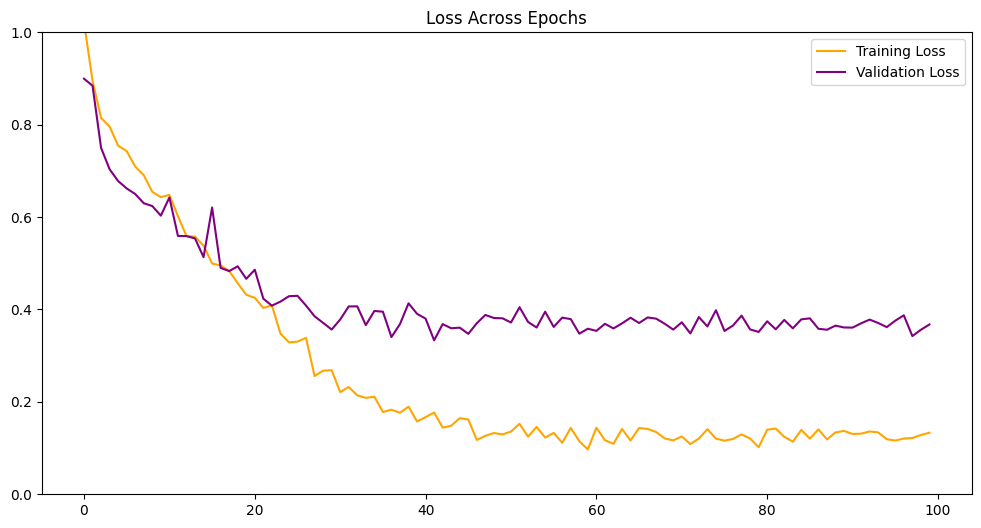

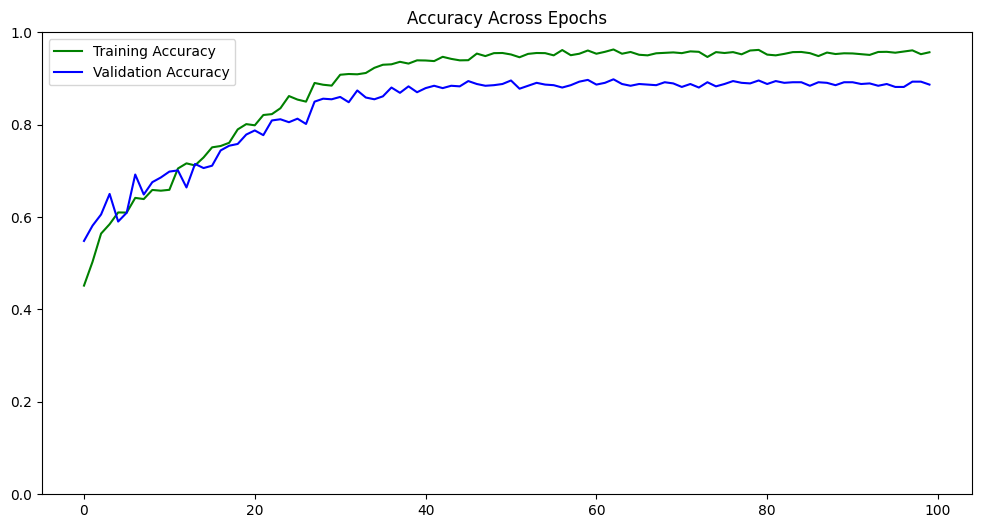

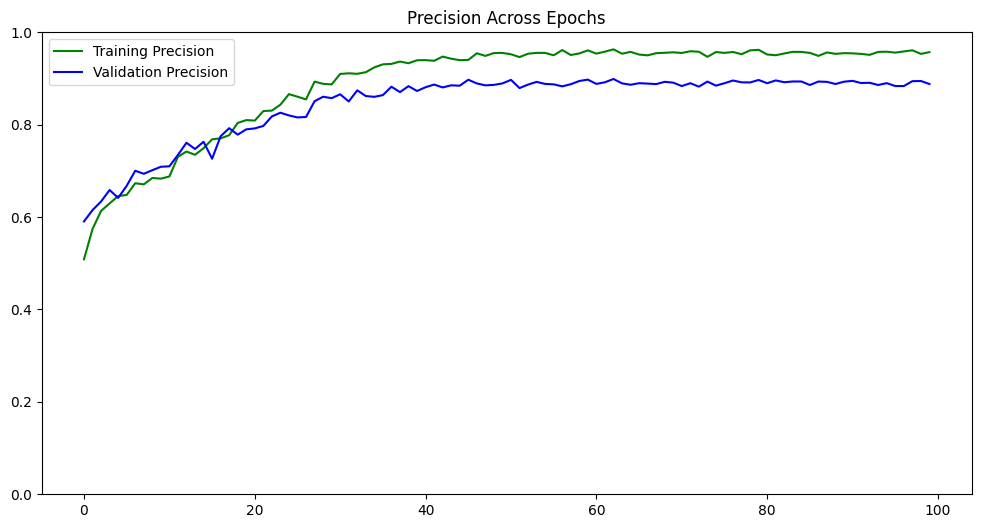

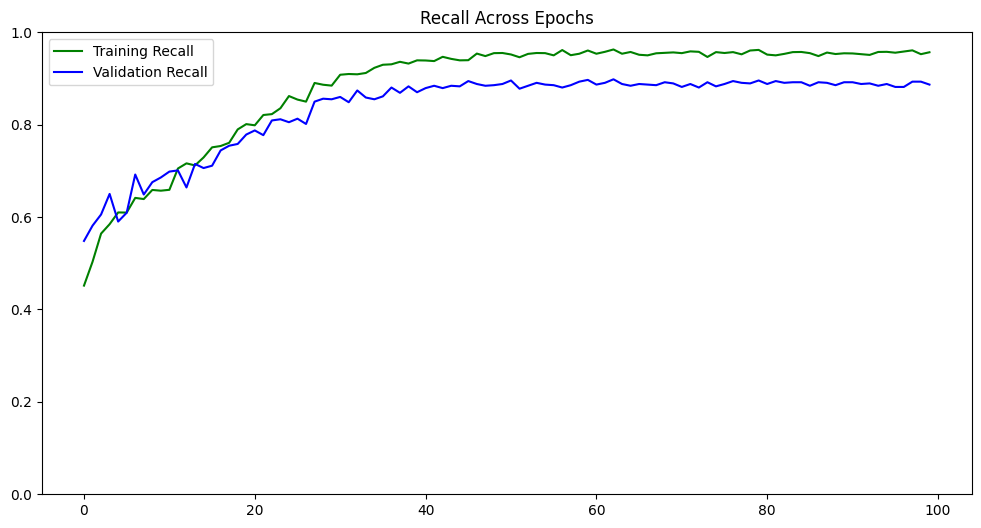

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_score, recall_score, accuracy_score
import matplotlib.pyplot as plt

# Assume X and y are your full dataset arrays
# X: shape (samples, 16, 4) – input sequences
# y: shape (samples,) – integer labels {0, 1, 2}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Compute class weights
unique_classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=y)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# Split data into training and validation sets
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_full, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_full, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_full, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_full, dtype=torch.long)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Define the CNN-LSTM model
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.lstm1 = nn.LSTM(input_size=512, hidden_size=128, batch_first=True, dropout=0.2, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc1 = nn.Linear(128, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = x.permute(0, 2, 1).reshape(x.shape[0], 4, 512)
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        x = self.dropout(x[:, -1, :])
        x = self.fc1(x * torch.sigmoid(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Initialize model
model = CNNLSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

# Tracking metrics across epochs
train_loss, val_loss = [], []
train_precision, val_precision = [], []
train_recall, val_recall = [], []
train_accuracy, val_accuracy = [], []

# Training loop
best_val_loss = float('inf')
for epoch in range(100):
    model.train()
    epoch_train_loss = 0
    train_preds, train_labels = [], []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(y_batch.cpu().numpy())
    
    train_loss.append(epoch_train_loss / len(train_loader))
    train_precision.append(precision_score(train_labels, train_preds, average='weighted'))
    train_recall.append(recall_score(train_labels, train_preds, average='weighted'))
    train_accuracy.append(accuracy_score(train_labels, train_preds))
    
    model.eval()
    epoch_val_loss = 0
    val_preds, val_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(y_batch.cpu().numpy())
    
    val_loss.append(epoch_val_loss / len(val_loader))
    val_precision.append(precision_score(val_labels, val_preds, average='weighted'))
    val_recall.append(recall_score(val_labels, val_preds, average='weighted'))
    val_accuracy.append(accuracy_score(val_labels, val_preds))
    scheduler.step(epoch_val_loss / len(val_loader))
    
    print(f"Epoch {epoch+1}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Accuracy: {val_accuracy[-1]:.4f}")

    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        torch.save(model.state_dict(), "final_model_best.pth")

# Plot metrics
plt.figure(figsize=(12, 6))
plt.plot(train_loss, label='Training Loss', color='orange')
plt.plot(val_loss, label='Validation Loss', color='purple')
plt.ylim(0, 1.0)
plt.title('Loss Across Epochs')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(train_accuracy, label='Training Accuracy', color='green')
plt.plot(val_accuracy, label='Validation Accuracy', color='blue')
plt.ylim(0, 1.0)
plt.title('Accuracy Across Epochs')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(train_precision, label='Training Precision', color='green')
plt.plot(val_precision, label='Validation Precision', color='blue')
plt.ylim(0, 1.0)
plt.title('Precision Across Epochs')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(train_recall, label='Training Recall', color='green')
plt.plot(val_recall, label='Validation Recall', color='blue')
plt.ylim(0, 1.0)
plt.title('Recall Across Epochs')
plt.legend()
plt.show()


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
<ipython-input-8-a14e0a98c954>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

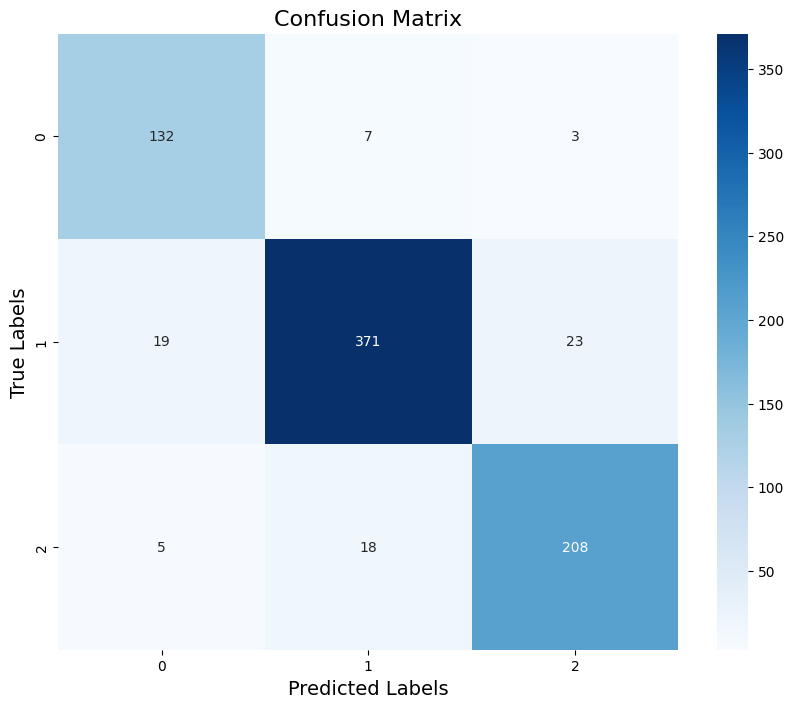

In [8]:
import torch
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the saved model's state dictionary
model = CNNLSTM()  # Ensure the same architecture used during training
model.load_state_dict(torch.load("/kaggle/input/cnn-lstm-tuned/pytorch/default/1/final_model_best (2).pth"))
model = model.to(device)  # Move the model to GPU/CPU
model.eval()  # Set the model to evaluation mode

# Collect predictions and labels from the validation dataset
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()  # Predicted labels
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())  # True labels

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=unique_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.show()


# BASELINE (multi class)

In [29]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns

# Assume X and y are your full dataset arrays:
# X: shape (samples, 16, 4) – input sequences
# y: shape (samples,) – integer labels {0, 1, 2}

# Flatten X for classical ML models (MLP, Logistic Regression, RF, SVM)
X_flat = X.reshape(X.shape[0], -1)  # shape becomes (samples, 16*4 = 64)

# Split data into training and validation sets (80/20 split), stratified by y
X_train_flat, X_val_flat, y_train_flat, y_val_flat = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

# Also, keep the original sequential data for the Keras MLP baseline if desired.
X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

########################################
# 1. MLP Baseline Model (using Keras)
########################################
print("=== MLP Baseline Model ===")
mlp_model = Sequential([
    Input(shape=(X_flat.shape[1],)),  # input shape: (64,)
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes
])
mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
mlp_history = mlp_model.fit(
    X_train_flat, y_train_flat,
    epochs=55,
    batch_size=16,
    validation_data=(X_val_flat, y_val_flat),
    callbacks=[early_stop],
    verbose=1
)
mlp_preds = mlp_model.predict(X_val_flat)
mlp_pred_classes = np.argmax(mlp_preds, axis=1)
mlp_acc = accuracy_score(y_val_flat, mlp_pred_classes)
mlp_prec = precision_score(y_val_flat, mlp_pred_classes, average='macro')
mlp_rec = recall_score(y_val_flat, mlp_pred_classes, average='macro')
mlp_f1 = f1_score(y_val_flat, mlp_pred_classes, average='macro')
print("MLP Baseline Metrics:")
print(f"Accuracy: {mlp_acc:.4f}")
print(f"Precision (macro): {mlp_prec:.4f}")
print(f"Recall (macro): {mlp_rec:.4f}")
print(f"F1 Score (macro): {mlp_f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val_flat, mlp_pred_classes))
print("\nClassification Report:")
print(classification_report(y_val_flat, mlp_pred_classes))


########################################
# 2. Logistic Regression Baseline
########################################
print("\n=== Logistic Regression Baseline ===")
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs', random_state=42)
logreg.fit(X_train_flat, y_train_flat)
y_pred_logreg = logreg.predict(X_val_flat)
logreg_acc = accuracy_score(y_val_flat, y_pred_logreg)
logreg_prec = precision_score(y_val_flat, y_pred_logreg, average='macro')
logreg_rec = recall_score(y_val_flat, y_pred_logreg, average='macro')
logreg_f1 = f1_score(y_val_flat, y_pred_logreg, average='macro')
print("Logistic Regression Metrics:")
print(f"Accuracy: {logreg_acc:.4f}")
print(f"Precision (macro): {logreg_prec:.4f}")
print(f"Recall (macro): {logreg_rec:.4f}")
print(f"F1 Score (macro): {logreg_f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val_flat, y_pred_logreg))
print("\nClassification Report:")
print(classification_report(y_val_flat, y_pred_logreg))


########################################
# 3. Random Forest Baseline
########################################
print("\n=== Random Forest Baseline ===")
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train_flat)
y_pred_rf = rf.predict(X_val_flat)
rf_acc = accuracy_score(y_val_flat, y_pred_rf)
rf_prec = precision_score(y_val_flat, y_pred_rf, average='macro')
rf_rec = recall_score(y_val_flat, y_pred_rf, average='macro')
rf_f1 = f1_score(y_val_flat, y_pred_rf, average='macro')
print("Random Forest Metrics:")
print(f"Accuracy: {rf_acc:.4f}")
print(f"Precision (macro): {rf_prec:.4f}")
print(f"Recall (macro): {rf_rec:.4f}")
print(f"F1 Score (macro): {rf_f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val_flat, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_val_flat, y_pred_rf))


########################################
# 4. SVM Baseline
########################################
print("\n=== SVM Baseline ===")
from sklearn.svm import SVC
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_flat, y_train_flat)
y_pred_svm = svm.predict(X_val_flat)
svm_acc = accuracy_score(y_val_flat, y_pred_svm)
svm_prec = precision_score(y_val_flat, y_pred_svm, average='macro')
svm_rec = recall_score(y_val_flat, y_pred_svm, average='macro')
svm_f1 = f1_score(y_val_flat, y_pred_svm, average='macro')
print("SVM Metrics:")
print(f"Accuracy: {svm_acc:.4f}")
print(f"Precision (macro): {svm_prec:.4f}")
print(f"Recall (macro): {svm_rec:.4f}")
print(f"F1 Score (macro): {svm_f1:.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_val_flat, y_pred_svm))
print("\nClassification Report:")
print(classification_report(y_val_flat, y_pred_svm))


=== MLP Baseline Model ===
Epoch 1/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.4969 - loss: 1.0392 - val_accuracy: 0.5356 - val_loss: 0.9963
Epoch 2/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5347 - loss: 0.9941 - val_accuracy: 0.5280 - val_loss: 1.0041
Epoch 3/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5309 - loss: 0.9713 - val_accuracy: 0.5344 - val_loss: 0.9612
Epoch 4/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5332 - loss: 0.9508 - val_accuracy: 0.5344 - val_loss: 0.9455
Epoch 5/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5461 - loss: 0.9365 - val_accuracy: 0.5394 - val_loss: 0.9364
Epoch 6/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5395 - loss: 0.9281 - val_accuracy: 0.5483 - val_loss: 0.9311
Epoch 7/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5582 - loss: 0.9023 - val_accuracy: 0.5496 - val_loss: 0.9256
Epoch 8/55
197/197 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5539 - los

Optimal hyperparameter tuning

In [8]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import optuna
# from torch.utils.data import DataLoader, TensorDataset

# # Convert NumPy arrays to PyTorch tensors
# X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
# y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
# X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
# y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# # Move to GPU if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# X_train_tensor, y_train_tensor = X_train_tensor.to(device), y_train_tensor.to(device)
# X_test_tensor, y_test_tensor = X_test_tensor.to(device), y_test_tensor.to(device)

# # Create DataLoader for batch processing
# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# # Define the LSTM Model
# class LSTMModel(nn.Module):
#     def __init__(self, lstm_units1, lstm_units2, dropout1, dropout2, l2_reg):
#         super(LSTMModel, self).__init__()
#         self.batch_norm = nn.BatchNorm1d(4)  # Normalize features (4 features per timestep)

#         self.lstm1 = nn.LSTM(input_size=4, hidden_size=lstm_units1, batch_first=True)
#         self.dropout1 = nn.Dropout(dropout1)

#         self.lstm2 = nn.LSTM(input_size=lstm_units1, hidden_size=lstm_units2, batch_first=True)
#         self.dropout2 = nn.Dropout(dropout2)

#         self.fc1 = nn.Linear(lstm_units2, 16)
#         self.relu = nn.ReLU()
#         self.fc2 = nn.Linear(16, 1)  # Binary classification output
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         x = x.permute(0, 2, 1)  # Swap to (batch, features, timesteps) for BatchNorm
#         x = self.batch_norm(x)
#         x = x.permute(0, 2, 1)  # Convert back to (batch, timesteps, features)

#         x, _ = self.lstm1(x)
#         x = self.dropout1(x)

#         x, _ = self.lstm2(x)
#         x = self.dropout2(x)

#         x = self.fc1(x[:, -1, :])  # Take last time step's output
#         x = self.relu(x)
#         x = self.fc2(x)
#         x = self.sigmoid(x)
#         return x

# # Objective function for Optuna
# def objective(trial):
#     lstm_units1 = trial.suggest_int("lstm_units1", 32, 128, step=32)
#     lstm_units2 = trial.suggest_int("lstm_units2", 32, 128, step=32)
#     dropout1 = trial.suggest_float("dropout1", 0.2, 0.4, step=0.1)
#     dropout2 = trial.suggest_float("dropout2", 0.2, 0.4, step=0.1)
#     l2_reg = trial.suggest_float("l2_reg", 0.0001, 0.01, log=True)
#     lr = trial.suggest_categorical("lr", [0.0001, 0.0005, 0.001])

#     model = LSTMModel(lstm_units1, lstm_units2, dropout1, dropout2, l2_reg).to(device)
#     criterion = nn.BCELoss()
#     optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2_reg)

#     # Training loop
#     model.train()
#     for epoch in range(25):  # Use small epochs for testing
#         total_loss = 0
#         for batch_X, batch_y in train_loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)

#             optimizer.zero_grad()
#             y_pred = model(batch_X).squeeze()
#             loss = criterion(y_pred, batch_y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         avg_loss = total_loss / len(train_loader)

#     # Validation
#     model.eval()
#     with torch.no_grad():
#         y_pred = model(X_test_tensor).squeeze()
#         val_loss = criterion(y_pred, y_test_tensor).item()

#     return val_loss

# # Optuna Hyperparameter Tuning
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=20)

# # Print best hyperparameters
# print("Best Hyperparameters:", study.best_params)


[I 2025-02-23 18:17:08,045] A new study created in memory with name: no-name-4d726cf9-67f9-401f-af43-b4b62dcbb185
[I 2025-02-23 18:17:20,689] Trial 0 finished with value: 0.4011944830417633 and parameters: {'lstm_units1': 64, 'lstm_units2': 32, 'dropout1': 0.2, 'dropout2': 0.4, 'l2_reg': 0.00017821494008700653, 'lr': 0.0005}. Best is trial 0 with value: 0.4011944830417633.
[I 2025-02-23 18:17:31,156] Trial 1 finished with value: 0.40893909335136414 and parameters: {'lstm_units1': 128, 'lstm_units2': 32, 'dropout1': 0.4, 'dropout2': 0.4, 'l2_reg': 0.00010619888212598145, 'lr': 0.0005}. Best is trial 0 with value: 0.4011944830417633.
[I 2025-02-23 18:17:41,221] Trial 2 finished with value: 0.40961092710494995 and parameters: {'lstm_units1': 64, 'lstm_units2': 32, 'dropout1': 0.2, 'dropout2': 0.2, 'l2_reg': 0.000530078940540869, 'lr': 0.001}. Best is trial 0 with value: 0.4011944830417633.
[I 2025-02-23 18:17:51,354] Trial 3 finished with value: 0.4070395529270172 and parameters: {'lstm_u

Best Hyperparameters: {'lstm_units1': 32, 'lstm_units2': 64, 'dropout1': 0.30000000000000004, 'dropout2': 0.30000000000000004, 'l2_reg': 0.00011957036271097843, 'lr': 0.0005}


# including MET variable( Metabolic equivalent of task)

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score

##############################################
# Load Sleep Data
##############################################
sleep_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/minuteSleep_merged.csv', parse_dates=['date'])
sleep_df['SleepDate'] = sleep_df['date'].dt.date.astype('datetime64[ns]')
daily_sleep = sleep_df.groupby(['Id', 'SleepDate'])['value'].value_counts().unstack(fill_value=0)
daily_sleep.rename(columns={1: 'TotalMinutesAsleep', 2: 'RestlessMinutes', 3: 'AwakeMinutes'}, inplace=True)
daily_sleep = daily_sleep.reset_index()

def classify_sleep_quality(total_sleep, restless_mins):
    if total_sleep >= 390 and restless_mins <= 20:
        return 2  # Good Sleep
    elif total_sleep >= 390 and restless_mins > 20:
        return 1  # Moderate Sleep
    elif total_sleep >= 300 and restless_mins <= 30:
        return 1  # Moderate Sleep
    else:
        return 0  # Poor Sleep

daily_sleep['SleepQuality'] = daily_sleep.apply(
    lambda row: classify_sleep_quality(row['TotalMinutesAsleep'], row['RestlessMinutes']), axis=1
)

##############################################
# Load Activity Data (Steps and Calories)
##############################################
steps_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv', parse_dates=['ActivityHour'])
calories_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv', parse_dates=['ActivityHour'])
activity_df = pd.merge(steps_df, calories_df, on=['Id', 'ActivityHour'])

##############################################
# Load Heart Rate Data
##############################################
heartrate_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/heartrate_seconds_merged.csv', parse_dates=['Time'])
heartrate_hourly = heartrate_df.groupby('Id').resample('H', on='Time').agg({'Value': 'mean'}).reset_index()

##############################################
# Load MET Data using ActivityMinute column
##############################################
mets_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/minuteMETsNarrow_merged.csv', parse_dates=['ActivityMinute'])
# Floor ActivityMinute to the hour
mets_df['Hour'] = mets_df['ActivityMinute'].dt.floor('H')
# Aggregate MET data by user and hour (mean MET value)
mets_hourly = mets_df.groupby(['Id', 'Hour']).agg({'METs': 'mean'}).reset_index()
mets_hourly.rename(columns={'METs': 'AvgMET'}, inplace=True)

##############################################
# Merge Activity, Heart Rate & MET Data
##############################################
merged_df = pd.merge(activity_df, heartrate_hourly, left_on=['Id', 'ActivityHour'], right_on=['Id', 'Time'], how='inner')
merged_df = pd.merge(merged_df, mets_hourly, left_on=['Id', 'ActivityHour'], right_on=['Id', 'Hour'], how='inner')
merged_df.drop(['Time', 'Hour'], axis=1, inplace=True)

##############################################
# Merge with Sleep Data
##############################################
merged_df['SleepDate'] = merged_df['ActivityHour'].dt.date.astype('datetime64[ns]')
final_df = pd.merge(
    merged_df,
    daily_sleep[['Id', 'SleepDate', 'SleepQuality']],
    left_on=['Id', 'SleepDate'],
    right_on=['Id', 'SleepDate'],
    how='inner'
)

##############################################
# Calculate Stress Level (Deviation from Resting HR)
##############################################
resting_hr = final_df.groupby('Id')['Value'].quantile(0.25).reset_index()
resting_hr.columns = ['Id', 'RestingHR']
final_df = pd.merge(final_df, resting_hr, on='Id')
final_df['StressLevel'] = final_df['Value'] - final_df['RestingHR']
final_df.drop('RestingHR', axis=1, inplace=True)

##############################################
# Keep Key Features & Rename for Consistency
##############################################
final_df = final_df[['Id', 'ActivityHour', 'StepTotal', 'Calories', 'Value', 'StressLevel', 'AvgMET', 'SleepQuality']]
final_df.columns = ['UserId', 'Hour', 'Steps', 'Calories', 'AvgHeartRate', 'StressLevel', 'AvgMET', 'SleepQuality']

print(final_df.head())


<ipython-input-2-7d02877355dc>:34: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  steps_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv', parse_dates=['ActivityHour'])
<ipython-input-2-7d02877355dc>:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calories_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.16/hourlyCalories_merged.csv', parse_dates=['ActivityHour'])
<ipython-input-2-7d02877355dc>:47: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  mets_df = pd.read_csv('/kaggle/input/fitbit/Fitabase Data 4.12.16-5.12.

       UserId                Hour  Steps  Calories  AvgHeartRate  StressLevel  \
0  2026352035 2016-04-17 05:00:00     36        50     67.198630    -9.949518   
1  2026352035 2016-04-17 06:00:00    214        69     73.282609    -3.865539   
2  2026352035 2016-04-17 07:00:00    116        63           NaN          NaN   
3  2026352035 2016-04-17 08:00:00    130        61           NaN          NaN   
4  2026352035 2016-04-17 09:00:00    119        61           NaN          NaN   

      AvgMET  SleepQuality  
0  10.766667             1  
1  14.883333             1  
2  13.616667             1  
3  13.083333             1  
4  13.183333             1  


In [3]:
final_df.dropna(inplace=True)

print(final_df[['Steps', 'Calories', 'AvgHeartRate', 'StressLevel','AvgMET']].describe())



             Steps     Calories  AvgHeartRate  StressLevel       AvgMET
count  4119.000000  4119.000000   4119.000000  4119.000000  4119.000000
mean    394.464433   107.841952     71.995596     8.845575    16.515477
std     656.599369    65.928932     13.447252    12.126416     8.993967
min       0.000000    50.000000     43.354037   -16.295497    10.000000
25%       6.000000    65.000000     62.428373    -0.000480    10.316667
50%     139.000000    85.000000     69.457584     6.663981    13.350000
75%     501.000000   124.000000     80.060421    15.246327    19.416667
max    5890.000000   612.000000    150.206208    78.910711    80.633333


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# -------------------------
# Data Preparation from final_df
# -------------------------
# Ensure your final_df has the following columns:
# 'UserId', 'Steps', 'Calories', 'AvgHeartRate', 'StressLevel', 'AvgMET', 'SleepQuality'
final_df.dropna(inplace=True)

# Normalize features: now include 'Steps', 'Calories', 'AvgHeartRate', 'StressLevel', and 'AvgMET'
scaler = MinMaxScaler()
features = scaler.fit_transform(final_df[['Steps', 'Calories', 'AvgHeartRate', 'StressLevel', 'AvgMET']])
labels = final_df['SleepQuality'].values

# Create sequences: each sample is a sequence of 16 timesteps (you can adjust seq_length)
def create_sequences(features, labels, user_ids, seq_length=16):
    X, y_out = [], []
    # Loop over each unique user
    for user_id in user_ids:
        # Create a mask to extract rows for the current user
        user_mask = (final_df['UserId'] == user_id)
        user_features = features[user_mask]
        user_labels = labels[user_mask]
        # Create sequences for this user
        for i in range(len(user_features) - seq_length):
            X.append(user_features[i:i+seq_length])
            y_out.append(user_labels[i+seq_length])
    return np.array(X), np.array(y_out)

# Get unique user IDs from final_df
unique_user_ids = final_df['UserId'].unique()

# Create sequences using the new feature set (now 5 features per timestep)
X, y = create_sequences(features, labels, unique_user_ids, seq_length=16)
print(f"✅ X shape: {X.shape}")   # Expected shape: (num_samples, 16, 5)
print(f"✅ y shape: {y.shape}")   # Expected shape: (num_samples,)


✅ X shape: (3930, 16, 5)
✅ y shape: (3930,)


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001, Train Loss: 1.0049, Val Loss: 1.0056, Val Acc: 0.5254
Epoch 002, Train Loss: 0.9930, Val Loss: 1.0147, Val Acc: 0.5254
Epoch 003, Train Loss: 0.9886, Val Loss: 1.0129, Val Acc: 0.5254
Epoch 004, Train Loss: 0.9884, Val Loss: 0.9918, Val Acc: 0.5254
Epoch 005, Train Loss: 0.9859, Val Loss: 0.9840, Val Acc: 0.5254
Epoch 006, Train Loss: 0.9750, Val Loss: 0.9792, Val Acc: 0.5242
Epoch 007, Train Loss: 0.9744, Val Loss: 0.9701, Val Acc: 0.5407
Epoch 008, Train Loss: 0.9699, Val Loss: 0.9790, Val Acc: 0.5267
Epoch 009, Train Loss: 0.9598, Val Loss: 0.9617, Val Acc: 0.5394
Epoch 010, Train Loss: 0.9491, Val Loss: 0.9580, Val Acc: 0.5407
Epoch 011, Train Loss: 0.9497, Val Loss: 0.9485, Val Acc: 0.5534
Epoch 012, Train Loss: 0.9228, Val Loss: 0.9481, Val Acc: 0.5534
Epoch 013, Train Loss: 0.9022, Val Loss: 0.8826, Val Acc: 0.5611
Epoch 014, Train Loss: 0.8690, Val Loss: 0.9078, Val Acc: 0.5598
Epoch 015, Train Loss: 0.8587, Val Loss: 0.8911, Val Acc: 0.5827
Epoch 016, Train Loss: 0.

<ipython-input-8-10f43e9d8b5a>:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("intermediate_lstm_model_best.pth"))


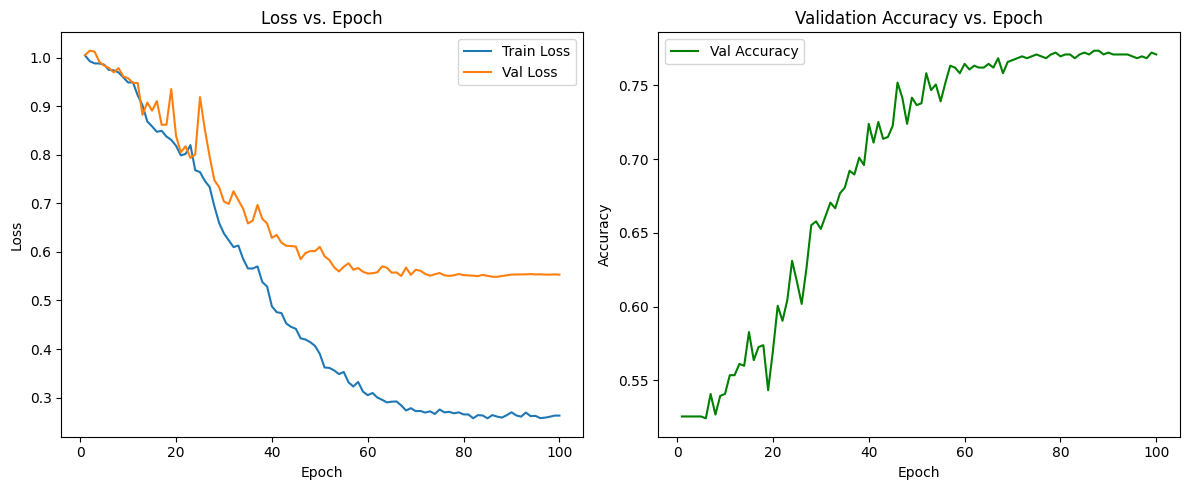

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Assume X and y are already created from your preprocessing:
# X: shape (num_samples, 16, 5) -- 16 timesteps, 5 features per timestep
# y: shape (num_samples,)       -- integer labels {0, 1, 2}
# For example:
# X = np.random.rand(1000, 16, 5)
# y = np.random.randint(0, 3, 1000)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert arrays to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create PyTorch datasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

##############################################
# Intermediate LSTM Baseline Model
##############################################
class IntermediateLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=2, num_classes=3, dropout=0.3):
        super(IntermediateLSTM, self).__init__()
        # Two-layer bidirectional LSTM
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True,
                            dropout=dropout)
        # Fully connected layers for classification
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        # x: (batch, 16, 5)
        lstm_out, _ = self.lstm(x)   # lstm_out shape: (batch, 16, hidden_size*2)
        # Use the last timestep's output as summary representation
        last_step = lstm_out[:, -1, :]  # (batch, hidden_size*2)
        logits = self.fc(last_step)     # (batch, num_classes)
        return logits

model = IntermediateLSTM(input_size=5, hidden_size=128, num_layers=2, num_classes=3, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

##############################################
# Training Loop with Metrics Logging
##############################################
num_epochs = 100
best_val_loss = float('inf')
metrics = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())
    val_loss /= len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    scheduler.step(val_loss)
    epoch_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1:03d}, Train Loss: {epoch_train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    
    metrics.append({
        "Epoch": epoch+1,
        "Train Loss": epoch_train_loss,
        "Val Loss": val_loss,
        "Val Accuracy": val_acc
    })
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "intermediate_lstm_model_best.pth")

model.load_state_dict(torch.load("intermediate_lstm_model_best.pth"))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

val_acc = accuracy_score(all_labels, all_preds)
val_precision = precision_score(all_labels, all_preds, average='macro')
val_recall = recall_score(all_labels, all_preds, average='macro')
print(f"Final Model Validation Accuracy: {val_acc:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}")

# Convert metrics to DataFrame and plot
metrics_df = pd.DataFrame(metrics)
print("\nTraining Metrics:")
print(metrics_df)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(metrics_df['Epoch'], metrics_df['Train Loss'], label='Train Loss')
plt.plot(metrics_df['Epoch'], metrics_df['Val Loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs. Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(metrics_df['Epoch'], metrics_df['Val Accuracy'], label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy vs. Epoch')
plt.legend()
plt.tight_layout()
plt.show()


✅ X shape: (3930, 16, 5)
✅ y shape: (3930,)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/rnn.py:88: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 001, Train Loss: 1.0227, Val Loss: 0.8637, Val Acc: 0.4593
Epoch 002, Train Loss: 0.8919, Val Loss: 0.8023, Val Acc: 0.5305
Epoch 003, Train Loss: 0.8585, Val Loss: 0.7912, Val Acc: 0.5191
Epoch 004, Train Loss: 0.8138, Val Loss: 0.7389, Val Acc: 0.5802
Epoch 005, Train Loss: 0.7767, Val Loss: 0.6906, Val Acc: 0.6031
Epoch 006, Train Loss: 0.7625, Val Loss: 0.7125, Val Acc: 0.6069
Epoch 007, Train Loss: 0.7177, Val Loss: 0.6711, Val Acc: 0.6781
Epoch 008, Train Loss: 0.7062, Val Loss: 0.6339, Val Acc: 0.6247
Epoch 009, Train Loss: 0.6682, Val Loss: 0.6711, Val Acc: 0.6870
Epoch 010, Train Loss: 0.6433, Val Loss: 0.6375, Val Acc: 0.6476
Epoch 011, Train Loss: 0.6245, Val Loss: 0.6180, Val Acc: 0.7226
Epoch 012, Train Loss: 0.6010, Val Loss: 0.5752, Val Acc: 0.6590
Epoch 013, Train Loss: 0.5847, Val Loss: 0.5253, Val Acc: 0.7036
Epoch 014, Train Loss: 0.5546, Val Loss: 0.5613, Val Acc: 0.7239
Epoch 015, Train Loss: 0.5465, Val Loss: 0.5572, Val Acc: 0.7303
Epoch 016, Train Loss: 0.

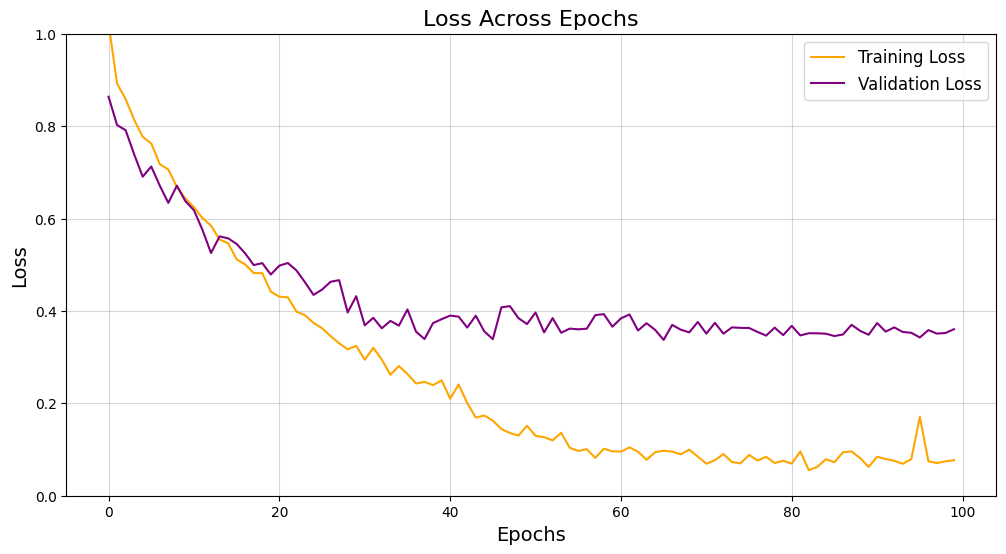

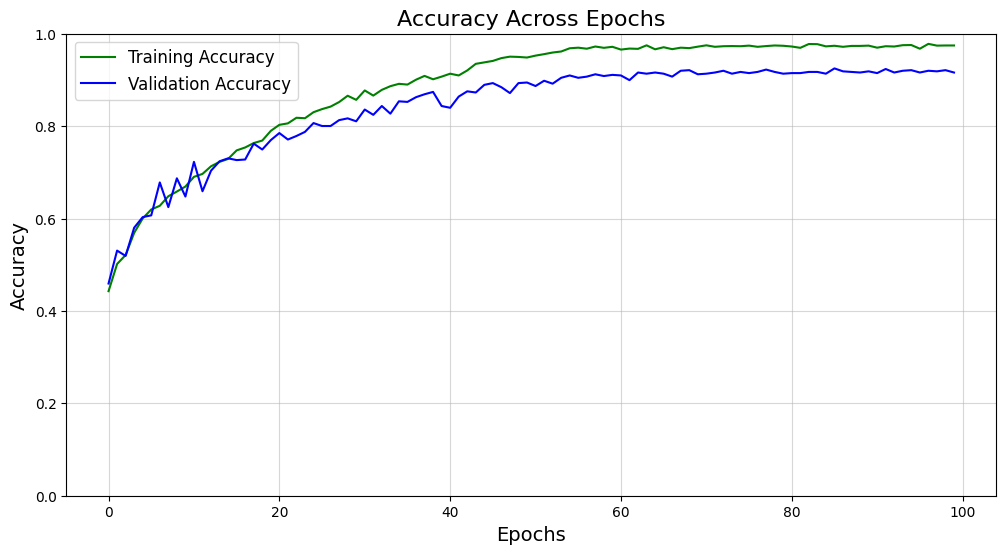

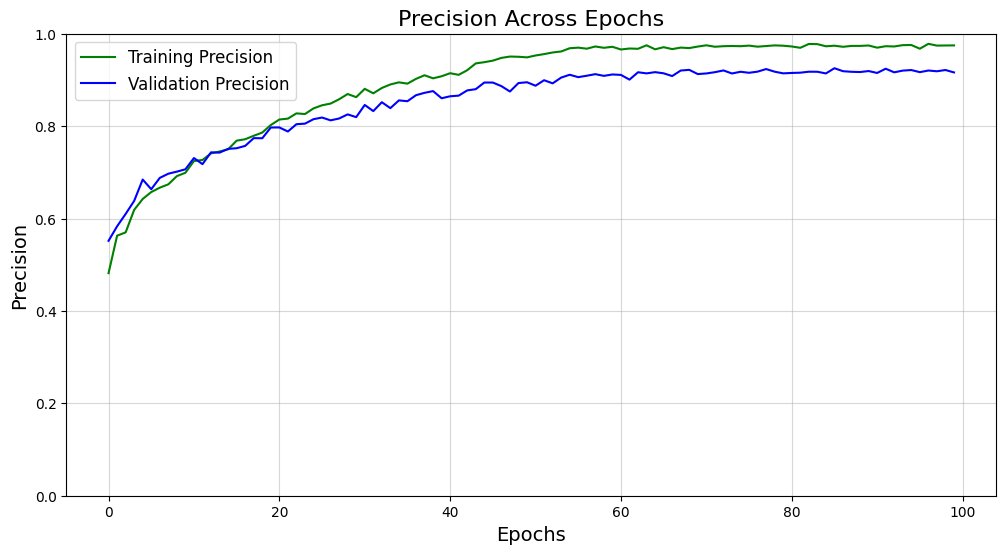

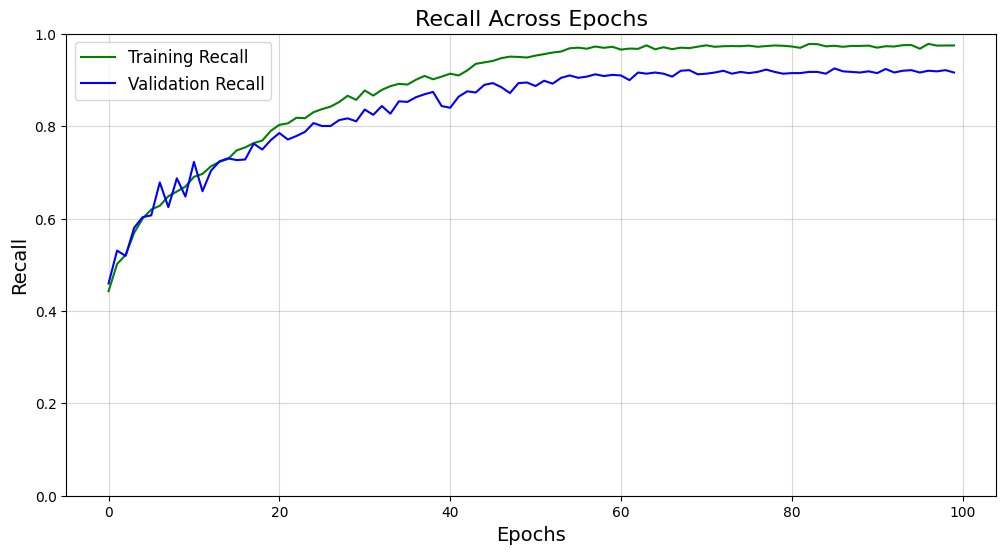

AttributeError: 'CNNLSTM' object has no attribute 'load_state'

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

##############################################
# Data Preparation
##############################################
final_df.dropna(inplace=True)

# Normalize features
scaler = MinMaxScaler()
features = scaler.fit_transform(final_df[['Steps', 'Calories', 'AvgHeartRate', 'StressLevel', 'AvgMET']])
labels = final_df['SleepQuality'].values

def create_sequences(features, labels, user_ids, seq_length=16):
    X, y = [], []
    for user_id in user_ids:
        user_mask = (final_df['UserId'] == user_id)
        user_features = features[user_mask]
        user_labels = labels[user_mask]
        for i in range(len(user_features) - seq_length):
            X.append(user_features[i:i+seq_length])
            y.append(user_labels[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(features, labels, final_df['UserId'].unique())
print(f"✅ X shape: {X.shape}")   # Expected shape: (num_samples, 16, 5)
print(f"✅ y shape: {y.shape}")   # Expected shape: (num_samples,)

##############################################
# Create PyTorch Datasets & DataLoaders
##############################################
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

unique_classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=unique_classes, y=y)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train_full, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_full, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_full, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_full, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

##############################################
# CNN-LSTM Model
##############################################
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=5, out_channels=64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout = nn.Dropout(0.3)
        self.lstm1 = nn.LSTM(input_size=512, hidden_size=128, batch_first=True, dropout=0.2, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, dropout=0.2, bidirectional=True)
        self.fc1 = nn.Linear(128, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.dropout(x)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.dropout(x)
        x = x.permute(0, 2, 1).reshape(x.shape[0], 4, 512)
        x, _ = self.lstm1(x)
        x = self.dropout(x)
        x, _ = self.lstm2(x)
        x = self.dropout(x[:, -1, :])
        x = self.fc1(x * torch.sigmoid(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

##############################################
# Training Setup
##############################################
model = CNNLSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

train_loss, val_loss = [], []
train_precision, val_precision = [], []
train_recall, val_recall = [], []
train_accuracy, val_accuracy = [], []

##############################################
# Training Loop with Metrics Tracking
##############################################
best_val_loss = float('inf')
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    epoch_train_loss = 0
    train_preds, train_labels = [], []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(y_batch.cpu().numpy())
    
    train_loss.append(epoch_train_loss / len(train_loader))
    train_precision.append(precision_score(train_labels, train_preds, average='weighted'))
    train_recall.append(recall_score(train_labels, train_preds, average='weighted'))
    train_accuracy.append(accuracy_score(train_labels, train_preds))
    
    model.eval()
    epoch_val_loss = 0
    val_preds, val_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(y_batch.cpu().numpy())
    
    val_loss.append(epoch_val_loss / len(val_loader))
    val_precision.append(precision_score(val_labels, val_preds, average='weighted'))
    val_recall.append(recall_score(val_labels, val_preds, average='weighted'))
    val_accuracy.append(accuracy_score(val_labels, val_preds))
    scheduler.step(epoch_val_loss / len(val_loader))
    
    print(f"Epoch {epoch+1:03d}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Acc: {val_accuracy[-1]:.4f}")
    
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        torch.save(model.state_dict(), "final_model_best.pth")

##############################################
# Plotting Metrics
##############################################
# Plot Loss
plt.figure(figsize=(12, 6))
plt.plot(train_loss, label='Training Loss', color='orange')
plt.plot(val_loss, label='Validation Loss', color='purple')
plt.title('Loss Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Plot Accuracy
plt.figure(figsize=(12, 6))
plt.plot(train_accuracy, label='Training Accuracy', color='green')
plt.plot(val_accuracy, label='Validation Accuracy', color='blue')
plt.title('Accuracy Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Plot Precision
plt.figure(figsize=(12, 6))
plt.plot(train_precision, label='Training Precision', color='green')
plt.plot(val_precision, label='Validation Precision', color='blue')
plt.title('Precision Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Plot Recall
plt.figure(figsize=(12, 6))
plt.plot(train_recall, label='Training Recall', color='green')
plt.plot(val_recall, label='Validation Recall', color='blue')
plt.title('Recall Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Recall', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

##############################################
# Confusion Matrix
##############################################
model.load_state

<ipython-input-18-77930d028bd7>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("final_model_best.pth"))


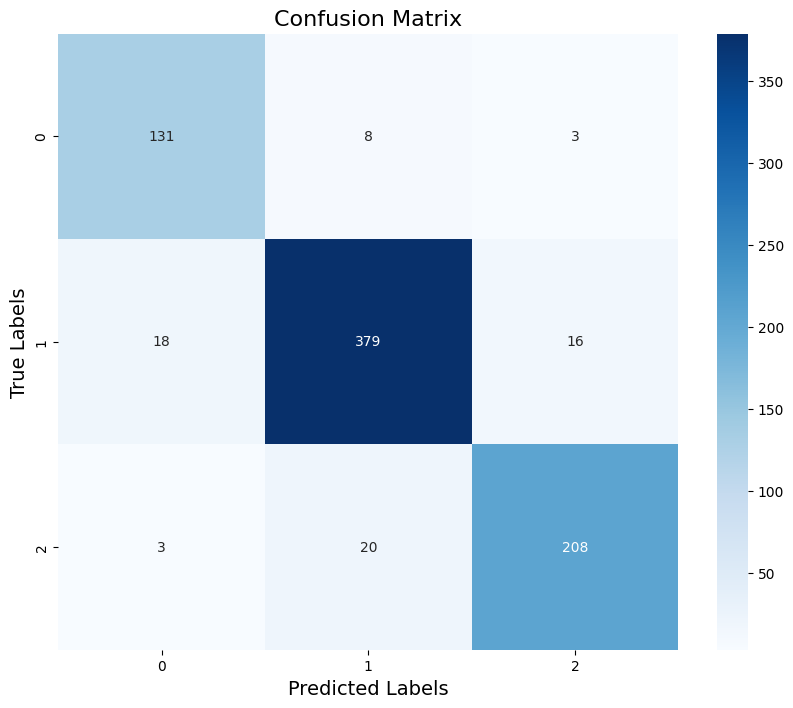

In [18]:
##############################################
# Confusion Matrix
##############################################
# Load the best model
model.load_state_dict(torch.load("final_model_best.pth"))
model.eval()

# Collect predictions and true labels
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()  # Predicted labels
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())  # True labels

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.show()


# Same LSTM model, without CNN layers

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 1, Train Loss: 1.0007, Val Loss: 1.0015, Val Accuracy: 0.5254


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 2, Train Loss: 0.9874, Val Loss: 0.9892, Val Accuracy: 0.5191


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Epoch 3, Train Loss: 0.9915, Val Loss: 0.9925, Val Accuracy: 0.5254
Epoch 4, Train Loss: 0.9742, Val Loss: 0.9688, Val Accuracy: 0.4911
Epoch 5, Train Loss: 0.9581, Val Loss: 0.9514, Val Accuracy: 0.4860
Epoch 6, Train Loss: 0.9433, Val Loss: 0.9585, Val Accuracy: 0.4924
Epoch 7, Train Loss: 0.9492, Val Loss: 0.9490, Val Accuracy: 0.5191
Epoch 8, Train Loss: 0.9349, Val Loss: 0.9379, Val Accuracy: 0.5267
Epoch 9, Train Loss: 0.9316, Val Loss: 0.9194, Val Accuracy: 0.5204
Epoch 10, Train Loss: 0.9067, Val Loss: 0.9036, Val Accuracy: 0.5369
Epoch 11, Train Loss: 0.8866, Val Loss: 0.8953, Val Accuracy: 0.5534
Epoch 12, Train Loss: 0.8786, Val Loss: 0.8899, Val Accuracy: 0.5598
Epoch 13, Train Loss: 0.8724, Val Loss: 0.8862, Val Accuracy: 0.5623
Epoch 14, Train Loss: 0.8625, Val Loss: 0.8683, Val Accuracy: 0.5611
Epoch 15, Train Loss: 0.8438, Val Loss: 0.8669, Val Accuracy: 0.5534
Epoch 16, Train Loss: 0.8439, Val Loss: 0.8923, Val Accuracy: 0.5356
Epoch 17, Train Loss: 0.8168, Val Loss: 0

<ipython-input-16-a3194fed7dc5>:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_lstm.load_state_dict(torch.load("lstm_model_best.pth"))


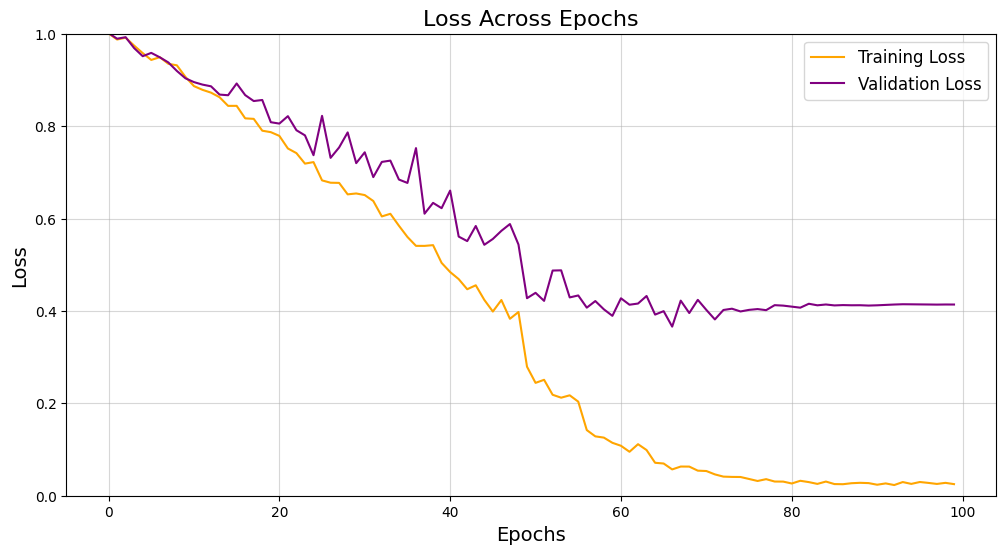

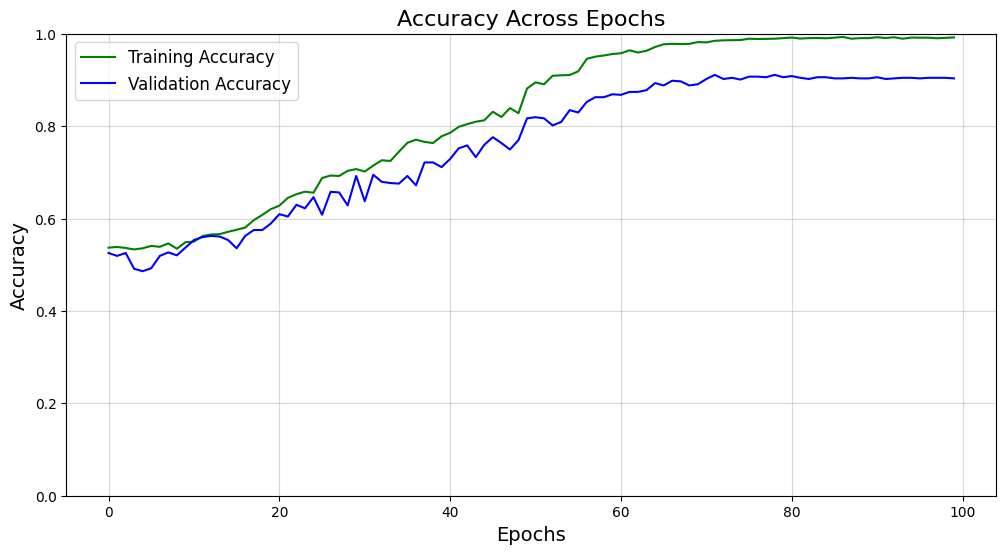

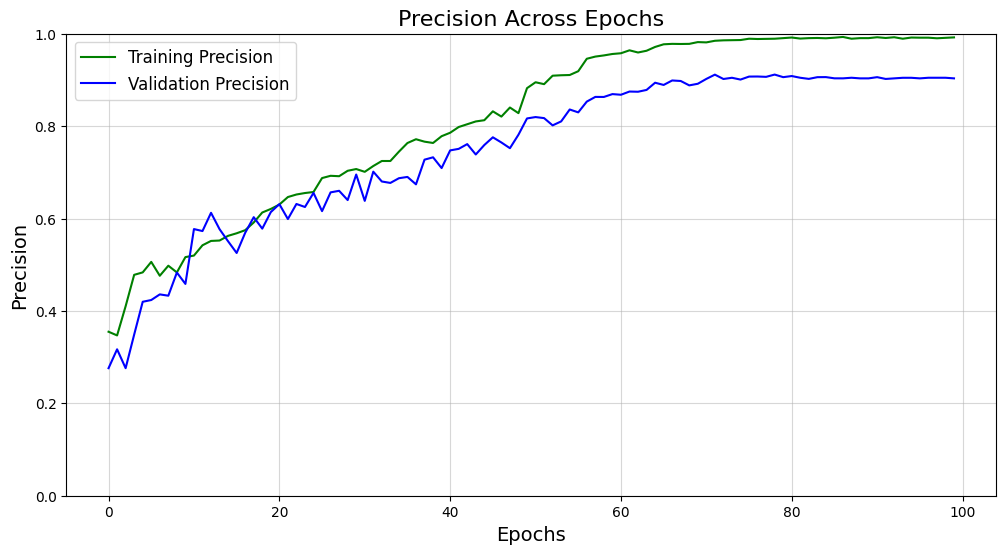

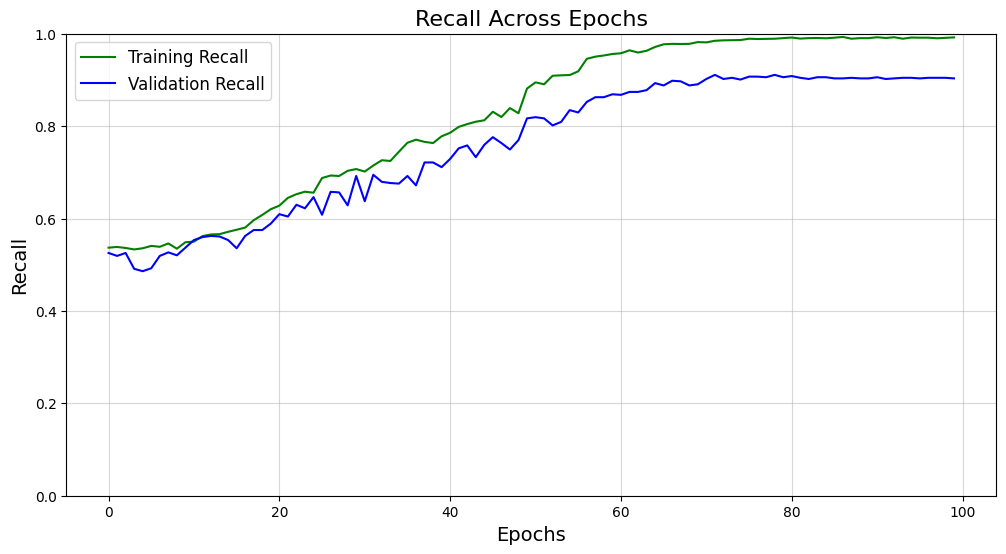

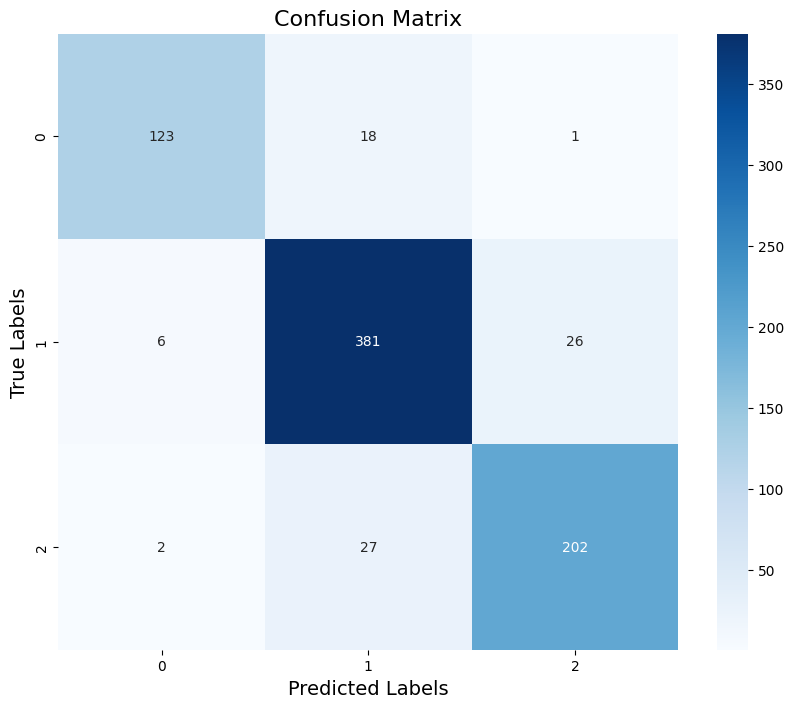

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Assume X and y are your full dataset arrays
# X shape: (num_samples, 16, 5)  -- 16 time steps, 5 features per step
# y shape: (num_samples,)        -- integer labels: {0, 1, 2}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Split data into training and validation sets
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_full, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_full, dtype=torch.long)
X_val_tensor = torch.tensor(X_val_full, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_full, dtype=torch.long)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Define the LSTM baseline model
class LSTMBaseline(nn.Module):
    def __init__(self, input_size=5, hidden_size=128, num_layers=2, num_classes=3, dropout=0.2):
        super(LSTMBaseline, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        logits = self.fc(out)
        return logits

# Initialize model, criterion, optimizer, and scheduler
model_lstm = LSTMBaseline(input_size=5, hidden_size=128, num_layers=2, num_classes=3, dropout=0.2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6, verbose=True)

# Tracking metrics across epochs
train_loss, val_loss = [], []
train_precision, val_precision = [], []
train_recall, val_recall = [], []
train_accuracy, val_accuracy = [], []

# Training Loop
best_val_loss = float('inf')
num_epochs = 100

for epoch in range(num_epochs):
    model_lstm.train()
    epoch_train_loss = 0
    train_preds, train_labels = [], []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model_lstm(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(y_batch.cpu().numpy())
    
    train_loss.append(epoch_train_loss / len(train_loader))
    train_precision.append(precision_score(train_labels, train_preds, average='weighted'))
    train_recall.append(recall_score(train_labels, train_preds, average='weighted'))
    train_accuracy.append(accuracy_score(train_labels, train_preds))
    
    model_lstm.eval()
    epoch_val_loss = 0
    val_preds, val_labels = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_lstm(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(y_batch.cpu().numpy())
    
    val_loss.append(epoch_val_loss / len(val_loader))
    val_precision.append(precision_score(val_labels, val_preds, average='weighted'))
    val_recall.append(recall_score(val_labels, val_preds, average='weighted'))
    val_accuracy.append(accuracy_score(val_labels, val_preds))
    scheduler.step(epoch_val_loss / len(val_loader))
    
    print(f"Epoch {epoch+1}, Train Loss: {train_loss[-1]:.4f}, Val Loss: {val_loss[-1]:.4f}, Val Accuracy: {val_accuracy[-1]:.4f}")
    
    if val_loss[-1] < best_val_loss:
        best_val_loss = val_loss[-1]
        torch.save(model_lstm.state_dict(), "lstm_model_best.pth")

# Load the best model for evaluation
model_lstm.load_state_dict(torch.load("lstm_model_best.pth"))
model_lstm.eval()

##############################################
# Plotting Metrics
##############################################
# Plot Loss
plt.figure(figsize=(12, 6))
plt.plot(train_loss, label='Training Loss', color='orange')
plt.plot(val_loss, label='Validation Loss', color='purple')
plt.title('Loss Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Plot Accuracy
plt.figure(figsize=(12, 6))
plt.plot(train_accuracy, label='Training Accuracy', color='green')
plt.plot(val_accuracy, label='Validation Accuracy', color='blue')
plt.title('Accuracy Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Plot Precision
plt.figure(figsize=(12, 6))
plt.plot(train_precision, label='Training Precision', color='green')
plt.plot(val_precision, label='Validation Precision', color='blue')
plt.title('Precision Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

# Plot Recall
plt.figure(figsize=(12, 6))
plt.plot(train_recall, label='Training Recall', color='green')
plt.plot(val_recall, label='Validation Recall', color='blue')
plt.title('Recall Across Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Recall', fontsize=14)
plt.ylim(0, 1.0)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()

##############################################
# Confusion Matrix
##############################################
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model_lstm(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1, 2], yticklabels=[0, 1, 2])
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Labels', fontsize=14)
plt.ylabel('True Labels', fontsize=14)
plt.show()


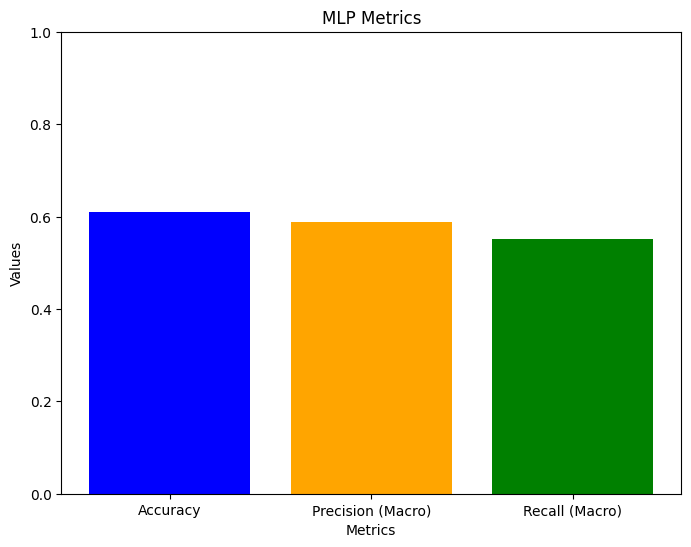

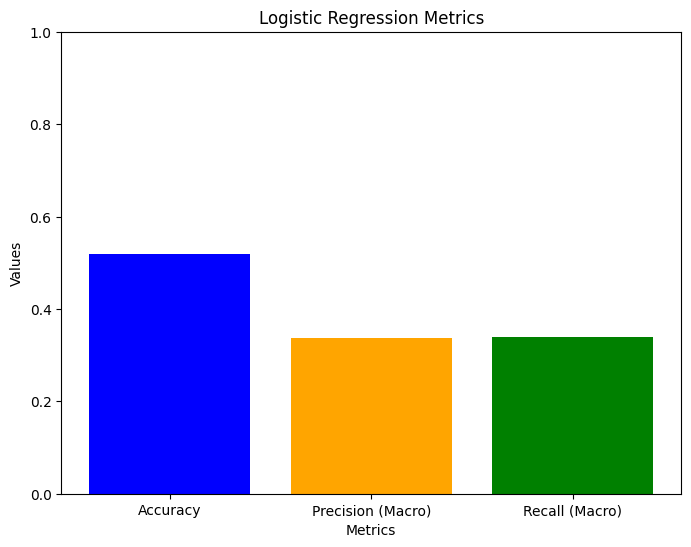

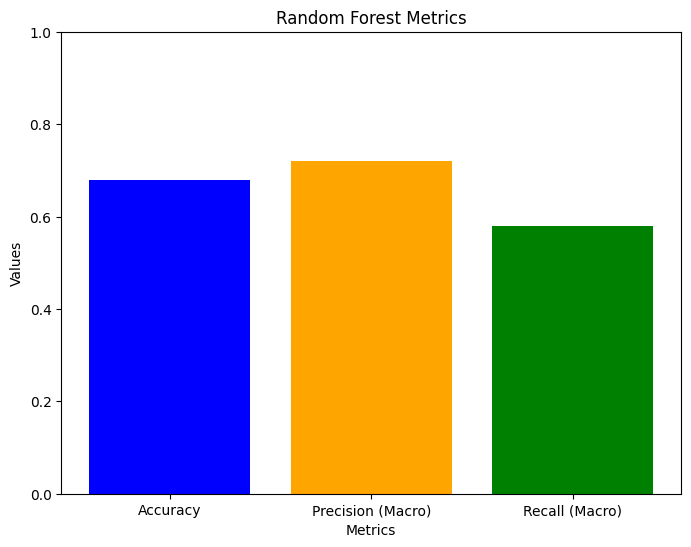

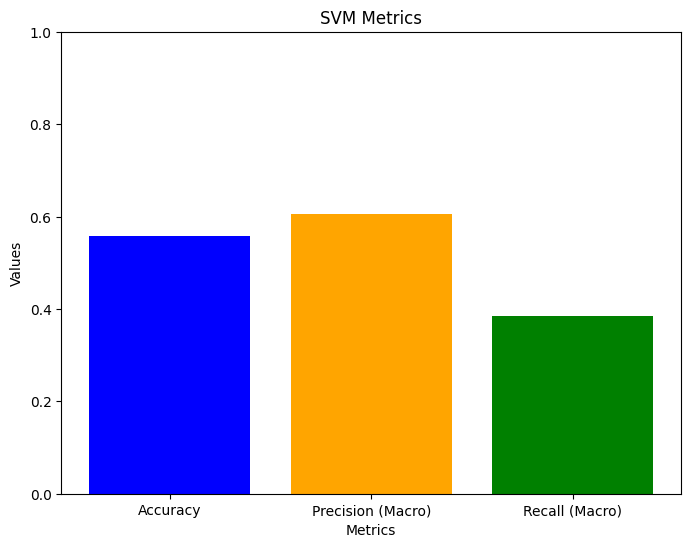

In [1]:
import matplotlib.pyplot as plt

# Data
models = ['MLP', 'Logistic Regression', 'Random Forest', 'SVM']
metrics = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)']
values = {
    'MLP': [0.6094, 0.5889, 0.5518],
    'Logistic Regression': [0.5178, 0.3380, 0.3385],
    'Random Forest': [0.6781, 0.7212, 0.5803],
    'SVM': [0.5573, 0.6050, 0.3836]
}

# Plotting function
def plot_metrics(model):
    plt.figure(figsize=(8, 6))
    plt.bar(metrics, values[model], color=['blue', 'orange', 'green'])
    plt.ylim(0, 1)
    plt.title(f'{model} Metrics')
    plt.xlabel('Metrics')
    plt.ylabel('Values')
    plt.show()

# Plot each model's metrics
for model in models:
    plot_metrics(model)